#TSP - Heuristic Implementation (Test)

In [ ]:
import math
import time
import heapq

# =========================
# Sample dataset
# =========================
cities = [
    {"x": 38.24, "y": 20.42},
    {"x": 39.57, "y": 26.15},
    {"x": 40.56, "y": 25.32},
    {"x": 36.26, "y": 23.12},
    {"x": 33.48, "y": 10.54},
    {"x": 37.56, "y": 12.19},
    {"x": 38.42, "y": 13.11},
    {"x": 37.52, "y": 20.44}
]

# =========================
# Distance helpers
# =========================
def dist(i, j):
    dx = cities[i]["x"] - cities[j]["x"]
    dy = cities[i]["y"] - cities[j]["y"]
    return math.sqrt(dx * dx + dy * dy)

def path_cost(path):
    total = 0.0
    for i in range(len(path) - 1):
        total += dist(path[i], path[i + 1])
    total += dist(path[-1], path[0])  # return to start
    return total

# Precompute distance matrix
n = len(cities)
D = [[dist(i, j) for j in range(n)] for i in range(n)]

# =========================
# Heuristics
# =========================
def heuristic_baseline(current, remaining, start=0):
    """
    Simple lower bound:
    shortest remaining edge * number of remaining cities
    """
    if not remaining:
        return D[current][start]

    shortest_edge = float("inf")

    # consider edges from current to remaining
    for c in remaining:
        shortest_edge = min(shortest_edge, D[current][c])

    # also consider edges among remaining cities
    rem_list = list(remaining)
    for i in range(len(rem_list)):
        for j in range(i + 1, len(rem_list)):
            shortest_edge = min(shortest_edge, D[rem_list[i]][rem_list[j]])

    # include possible return edge to start
    for c in remaining:
        shortest_edge = min(shortest_edge, D[c][start])

    return shortest_edge * (len(remaining) + 1)


def heuristic_improved(current, remaining, start=0):
    """
    Improved but still simple lower bound:
    1. minimum edge from current to remaining
    2. + minimum edge from remaining back to start
    3. + MST cost over remaining cities
    """
    if not remaining:
        return D[current][start]

    remaining = list(remaining)

    # min edge from current to any remaining
    min_to_remaining = min(D[current][c] for c in remaining)

    # min edge from any remaining back to start
    min_to_start = min(D[c][start] for c in remaining)

    # MST cost over remaining nodes using Prim's algorithm
    mst_cost = 0.0
    if len(remaining) > 1:
        visited = set()
        visited.add(remaining[0])

        while len(visited) < len(remaining):
            best = float("inf")
            best_node = None

            for u in visited:
                for v in remaining:
                    if v not in visited and D[u][v] < best:
                        best = D[u][v]
                        best_node = v

            mst_cost += best
            visited.add(best_node)

    return min_to_remaining + mst_cost + min_to_start

# =========================
# A* for TSP
# =========================
def astar_tsp(heuristic_func, start=0):
    """
    State:
      current city
      visited set (as bitmask)
      path
      g = distance traveled so far
    """
    all_visited_mask = (1 << n) - 1

    # priority queue entries: (f, g, current, visited_mask, path)
    pq = []
    start_mask = 1 << start
    h0 = heuristic_func(start, set(range(n)) - {start}, start)
    heapq.heappush(pq, (h0, 0.0, start, start_mask, [start]))

    best_g = {}
    best_g[(start, start_mask)] = 0.0

    nodes_expanded = 0

    while pq:
        f, g, current, visited_mask, path = heapq.heappop(pq)
        nodes_expanded += 1

        # goal: all cities visited
        if visited_mask == all_visited_mask:
            total = g + D[current][start]
            return {
                "path": path + [start],
                "tour_cost": total,
                "nodes_expanded": nodes_expanded
            }

        # expand children
        for nxt in range(n):
            if not (visited_mask & (1 << nxt)):
                new_mask = visited_mask | (1 << nxt)
                new_g = g + D[current][nxt]
                state_key = (nxt, new_mask)

                if state_key not in best_g or new_g < best_g[state_key]:
                    best_g[state_key] = new_g
                    remaining = {i for i in range(n) if not (new_mask & (1 << i))}
                    h = heuristic_func(nxt, remaining, start)
                    new_f = new_g + h
                    heapq.heappush(pq, (new_f, new_g, nxt, new_mask, path + [nxt]))

    return None

# =========================
# Run experiments
# =========================
def run_test(name, heuristic_func):
    t0 = time.time()
    result = astar_tsp(heuristic_func, start=0)
    elapsed = (time.time() - t0) * 1000

    print(f"=== {name} ===")
    print("Path:", result["path"])
    print("Tour cost:", round(result["tour_cost"], 2))
    print("Nodes expanded:", result["nodes_expanded"])
    print("Elapsed time (ms):", round(elapsed, 2))
    print()

run_test("Baseline Heuristic", heuristic_baseline)
run_test("Improved Heuristic (MST-based)", heuristic_improved)

=== Baseline Heuristic ===
Path: [0, 2, 1, 3, 7, 4, 5, 6, 0]
Tour cost: 37.83
Nodes expanded: 505
Elapsed time (ms): 4.93

=== Improved Heuristic (MST-based) ===
Path: [0, 2, 1, 3, 7, 4, 5, 6, 0]
Tour cost: 37.83
Nodes expanded: 65
Elapsed time (ms): 1.6



#Graphical Implementation


=== Dataset with 8 cities ===
Baseline: {'name': 'Baseline', 'tour_cost': 253.27750067749182, 'nodes_expanded': 240, 'runtime_ms': 2.9664039611816406}
Improved: {'name': 'Improved', 'tour_cost': 253.27750067749182, 'nodes_expanded': 16, 'runtime_ms': 0.4916191101074219}


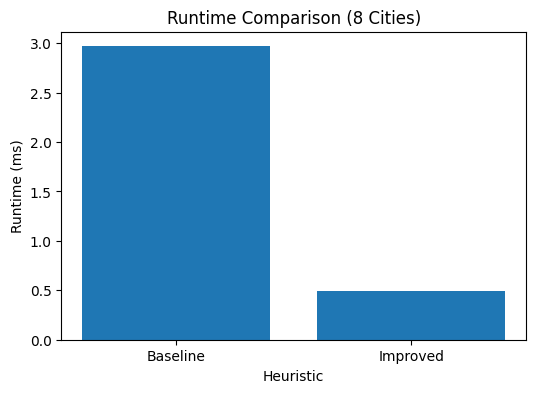

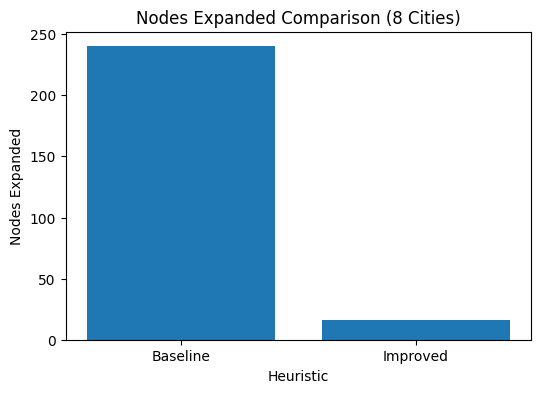


=== Dataset with 8 cities ===
Baseline: {'name': 'Baseline', 'tour_cost': 287.5383466872993, 'nodes_expanded': 341, 'runtime_ms': 11.624336242675781}
Improved: {'name': 'Improved', 'tour_cost': 287.5383466872993, 'nodes_expanded': 24, 'runtime_ms': 1.356363296508789}

=== Dataset with 9 cities ===
Baseline: {'name': 'Baseline', 'tour_cost': 248.52491436251563, 'nodes_expanded': 977, 'runtime_ms': 25.524377822875977}
Improved: {'name': 'Improved', 'tour_cost': 248.52491436251566, 'nodes_expanded': 32, 'runtime_ms': 2.529621124267578}

=== Dataset with 10 cities ===
Baseline: {'name': 'Baseline', 'tour_cost': 244.90746601855554, 'nodes_expanded': 1892, 'runtime_ms': 57.12127685546875}
Improved: {'name': 'Improved', 'tour_cost': 244.90746601855554, 'nodes_expanded': 37, 'runtime_ms': 4.125833511352539}


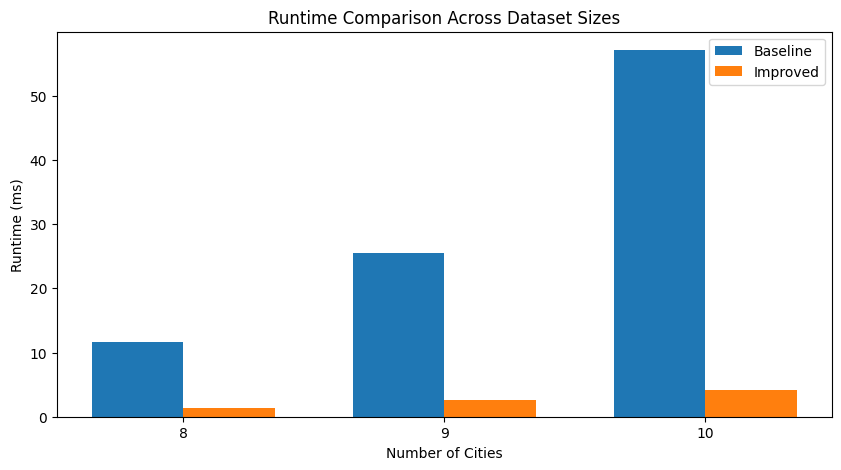

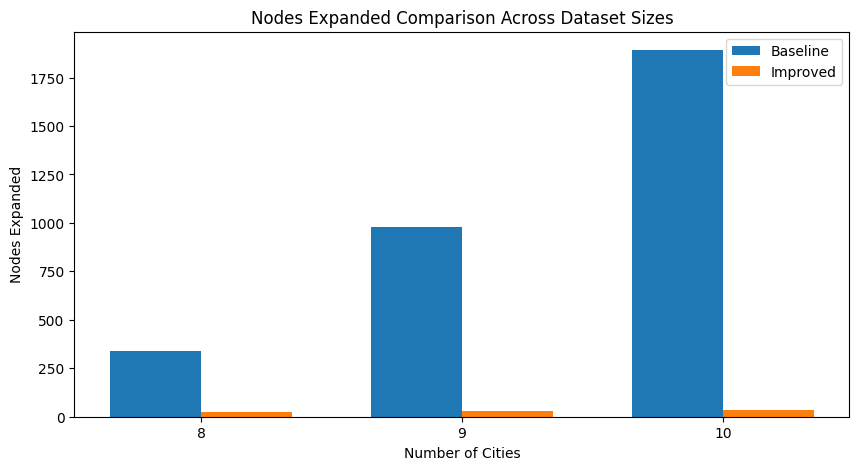

In [ ]:
import random
import matplotlib.pyplot as plt

# =========================
# Dataset generator
# =========================
def generate_cities(num_cities, seed=42):
    random.seed(seed)
    return [{"x": random.uniform(0, 100), "y": random.uniform(0, 100)} for _ in range(num_cities)]

# =========================
# Reset global dataset
# =========================
def set_dataset(new_cities):
    global cities, n, D
    cities = new_cities
    n = len(cities)
    D = [[dist(i, j) for j in range(n)] for i in range(n)]

# =========================
# Benchmark one heuristic
# =========================
def benchmark_heuristic(name, heuristic_func):
    t0 = time.time()
    result = astar_tsp(heuristic_func, start=0)
    elapsed = (time.time() - t0) * 1000

    return {
        "name": name,
        "tour_cost": result["tour_cost"],
        "nodes_expanded": result["nodes_expanded"],
        "runtime_ms": elapsed
    }

# =========================
# Run experiment for one dataset size
# =========================
def run_single_experiment(num_cities, seed=42):
    new_cities = generate_cities(num_cities, seed=seed)
    set_dataset(new_cities)

    baseline_result = benchmark_heuristic("Baseline", heuristic_baseline)
    improved_result = benchmark_heuristic("Improved", heuristic_improved)

    print(f"\n=== Dataset with {num_cities} cities ===")
    print("Baseline:", baseline_result)
    print("Improved:", improved_result)

    return baseline_result, improved_result

# =========================
# Plot bar charts for one dataset size
# =========================
def plot_single_dataset_bars(num_cities, seed=42):
    baseline_result, improved_result = run_single_experiment(num_cities, seed)

    labels = ["Baseline", "Improved"]
    runtimes = [baseline_result["runtime_ms"], improved_result["runtime_ms"]]
    nodes = [baseline_result["nodes_expanded"], improved_result["nodes_expanded"]]

    # Runtime bar chart
    plt.figure(figsize=(6, 4))
    plt.bar(labels, runtimes)
    plt.title(f"Runtime Comparison ({num_cities} Cities)")
    plt.xlabel("Heuristic")
    plt.ylabel("Runtime (ms)")
    plt.show()

    # Nodes expanded bar chart
    plt.figure(figsize=(6, 4))
    plt.bar(labels, nodes)
    plt.title(f"Nodes Expanded Comparison ({num_cities} Cities)")
    plt.xlabel("Heuristic")
    plt.ylabel("Nodes Expanded")
    plt.show()

# =========================
# Run multiple dataset sizes
# =========================
def run_multiple_sizes(city_sizes, seed=42):
    baseline_runtimes = []
    improved_runtimes = []

    baseline_nodes = []
    improved_nodes = []

    for size in city_sizes:
        baseline_result, improved_result = run_single_experiment(size, seed + size)

        baseline_runtimes.append(baseline_result["runtime_ms"])
        improved_runtimes.append(improved_result["runtime_ms"])

        baseline_nodes.append(baseline_result["nodes_expanded"])
        improved_nodes.append(improved_result["nodes_expanded"])

    x = range(len(city_sizes))
    labels = [str(size) for size in city_sizes]

    # Runtime bar chart
    plt.figure(figsize=(10, 5))
    width = 0.35
    plt.bar([i - width/2 for i in x], baseline_runtimes, width=width, label="Baseline")
    plt.bar([i + width/2 for i in x], improved_runtimes, width=width, label="Improved")
    plt.title("Runtime Comparison Across Dataset Sizes")
    plt.xlabel("Number of Cities")
    plt.ylabel("Runtime (ms)")
    plt.xticks(list(x), labels)
    plt.legend()
    plt.show()

    # Nodes expanded bar chart
    plt.figure(figsize=(10, 5))
    plt.bar([i - width/2 for i in x], baseline_nodes, width=width, label="Baseline")
    plt.bar([i + width/2 for i in x], improved_nodes, width=width, label="Improved")
    plt.title("Nodes Expanded Comparison Across Dataset Sizes")
    plt.xlabel("Number of Cities")
    plt.ylabel("Nodes Expanded")
    plt.xticks(list(x), labels)
    plt.legend()
    plt.show()

# =========================
# Example runs
# =========================

# For a single size:
plot_single_dataset_bars(8, seed=42)

# For multiple sizes:
run_multiple_sizes([8, 9, 10], seed=42)

#MST Heuristic Implementation Test

In [ ]:
def mst_cost(nodes, D):
    if len(nodes) <= 1:
        return 0

    nodes = list(nodes)
    visited = {nodes[0]}
    cost = 0

    while len(visited) < len(nodes):
        best = float("inf")
        best_node = None

        for u in visited:
            for v in nodes:
                if v not in visited and D[u][v] < best:
                    best = D[u][v]
                    best_node = v

        cost += best
        visited.add(best_node)

    return cost


def heuristic_mst(current, remaining, start, D):
    if not remaining:
        return D[current][start]

    remaining = set(remaining)

    min_to_remaining = min(D[current][c] for c in remaining)
    min_to_start = min(D[c][start] for c in remaining)

    mst = mst_cost(remaining, D)

    return min_to_remaining + mst + min_to_start

#Graphical Implementation

=== MST HEURISTIC (BEAM A*) RESULTS ===
Cities: 10 | Runtime: 24.87 ms | Cost: 267.64
Cities: 20 | Runtime: 412.38 ms | Cost: 356.77
Cities: 30 | Runtime: 3297.69 ms | Cost: 489.60
Cities: 40 | Runtime: 16686.31 ms | Cost: 514.33
Cities: 50 | Runtime: 53656.67 ms | Cost: 557.15


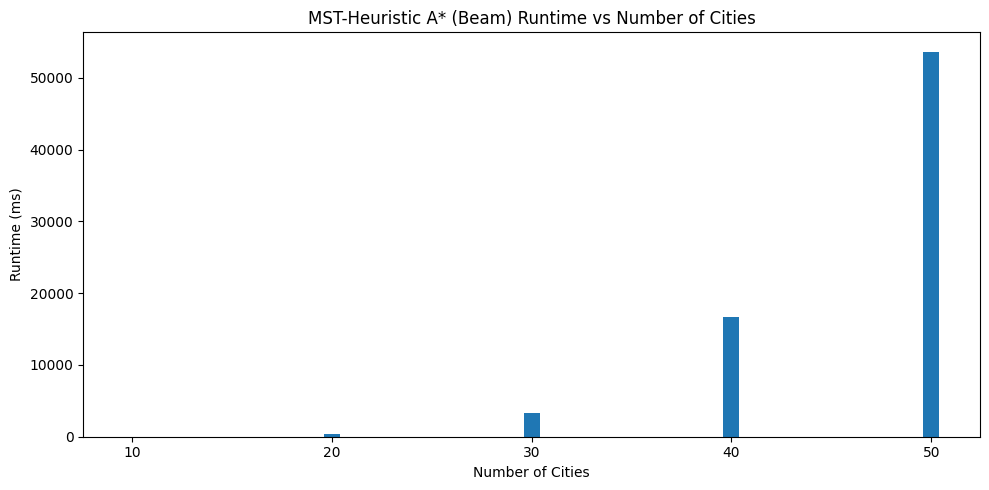

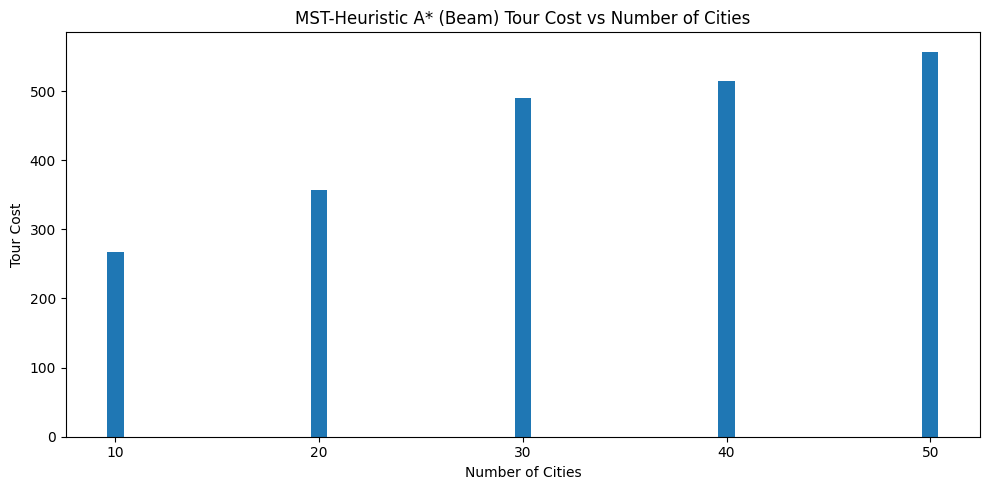

In [ ]:
import math
import time
import heapq
import random
import matplotlib.pyplot as plt

# =========================
# YOUR MST HEURISTIC
# =========================
def mst_cost(nodes, D):
    if len(nodes) <= 1:
        return 0

    nodes = list(nodes)
    visited = {nodes[0]}
    cost = 0

    while len(visited) < len(nodes):
        best = float("inf")
        best_node = None

        for u in visited:
            for v in nodes:
                if v not in visited and D[u][v] < best:
                    best = D[u][v]
                    best_node = v

        cost += best
        visited.add(best_node)

    return cost


def heuristic_mst(current, remaining, start, D):
    if not remaining:
        return D[current][start]

    remaining = set(remaining)

    min_to_remaining = min(D[current][c] for c in remaining)
    min_to_start = min(D[c][start] for c in remaining)
    mst = mst_cost(remaining, D)

    return min_to_remaining + mst + min_to_start


# =========================
# HELPERS
# =========================
def euclidean(p1, p2):
    return math.dist(p1, p2)


def build_distance_matrix(coords):
    n = len(coords)
    D = [[0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                D[i][j] = euclidean(coords[i], coords[j])
    return D


def generate_cities(n, seed=42):
    random.seed(seed)
    return [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(n)]


# =========================
# BEAM A* (SCALES WELL)
# =========================
def beam_astar_tsp(coords, beam_width=50, start=0):
    n = len(coords)
    D = build_distance_matrix(coords)

    initial = (0, start, frozenset([start]), [start])
    beam = [initial]

    for _ in range(n - 1):
        new_beam = []

        for g, current, visited, path in beam:
            remaining = set(range(n)) - set(visited)

            for nxt in remaining:
                new_g = g + D[current][nxt]
                new_visited = frozenset(set(visited) | {nxt})
                new_remaining = remaining - {nxt}

                h = heuristic_mst(nxt, new_remaining, start, D)
                f = new_g + h

                new_beam.append((new_g, nxt, new_visited, path + [nxt], f))

        # keep only best states
        new_beam.sort(key=lambda x: x[4])
        beam = [(g, curr, vis, p) for (g, curr, vis, p, _) in new_beam[:beam_width]]

    # close tour
    best_cost = float("inf")
    best_path = None

    for g, current, visited, path in beam:
        total = g + D[current][start]
        if total < best_cost:
            best_cost = total
            best_path = path + [start]

    return best_path, best_cost


# =========================
# BENCHMARK (MATCH YOUR OTHER GRAPHS)
# =========================
sizes = [10, 20, 30, 40, 50]

runtimes = []
costs = []

print("=== MST HEURISTIC (BEAM A*) RESULTS ===")

for n in sizes:
    coords = generate_cities(n, seed=100 + n)

    start_time = time.perf_counter()
    path, cost = beam_astar_tsp(coords, beam_width=50)
    end_time = time.perf_counter()

    runtime_ms = (end_time - start_time) * 1000

    runtimes.append(runtime_ms)
    costs.append(cost)

    print(f"Cities: {n} | Runtime: {runtime_ms:.2f} ms | Cost: {cost:.2f}")


# =========================
# GRAPH 1: RUNTIME
# =========================
plt.figure(figsize=(10, 5))
plt.bar(sizes, runtimes)
plt.title("MST-Heuristic A* (Beam) Runtime vs Number of Cities")
plt.xlabel("Number of Cities")
plt.ylabel("Runtime (ms)")
plt.xticks(sizes)
plt.tight_layout()
plt.show()


# =========================
# GRAPH 2: COST
# =========================
plt.figure(figsize=(10, 5))
plt.bar(sizes, costs)
plt.title("MST-Heuristic A* (Beam) Tour Cost vs Number of Cities")
plt.xlabel("Number of Cities")
plt.ylabel("Tour Cost")
plt.xticks(sizes)
plt.tight_layout()
plt.show()

#Nearest Neighbour (k-RNN) Implementation Test

#How it works:
Choose a starting city
Mark it as visited
From the current city, select the nearest unvisited city
Move to that city and mark it visited
Repeat until all cities are visited
Return to the starting city

This produces a complete tour.

**Multi-Start Extension** (k-NN)

A known improvement used in research is the multi-start version, sometimes referred to as k-NN.

Instead of running the algorithm once:

Run Nearest Neighbor from multiple starting cities
Compute a tour for each start
Select the best tour (lowest cost)

This helps reduce the dependency on the initial starting city, which is one of the main weaknesses of the basic NN approach.

In [ ]:
def nearest_neighbor(start, D):
    n = len(D)
    visited = {start}
    path = [start]
    current = start

    while len(visited) < n:
        next_city = min(
            [i for i in range(n) if i not in visited],
            key=lambda x: D[current][x]
        )
        path.append(next_city)
        visited.add(next_city)
        current = next_city

    path.append(start)  # return to start
    return path


def multi_start_nn(D):
    best_path = None
    best_cost = float("inf")

    for start in range(len(D)):
        path = nearest_neighbor(start, D)

        cost = 0
        for i in range(len(path) - 1):
            cost += D[path[i]][path[i+1]]

        if cost < best_cost:
            best_cost = cost
            best_path = path

    return best_path, best_cost

#Graphical Implementation

In [ ]:
import random
import time
import matplotlib.pyplot as plt

# =========================
# Generate random dataset
# =========================
def generate_cities(num_cities, seed=42):
    random.seed(seed)
    return [{"x": random.uniform(0, 100), "y": random.uniform(0, 100)} for _ in range(num_cities)]

# =========================
# Build distance matrix
# =========================
def build_distance_matrix(cities):
    n = len(cities)
    D = [[0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            dx = cities[i]["x"] - cities[j]["x"]
            dy = cities[i]["y"] - cities[j]["y"]
            D[i][j] = (dx*dx + dy*dy)**0.5
    return D

# =========================
# Benchmark NN
# =========================
def benchmark_nn(num_cities, seed=42):
    cities = generate_cities(num_cities, seed)
    D = build_distance_matrix(cities)

    t0 = time.time()
    path, cost = multi_start_nn(D)
    elapsed = (time.time() - t0) * 1000

    return {
        "size": num_cities,
        "runtime": elapsed,
        "cost": cost
    }

# =========================
# Run experiments for many sizes
# =========================
def run_nn_experiments(sizes):
    runtimes = []
    costs = []

    for size in sizes:
        result = benchmark_nn(size, seed=42 + size)

        print(f"Cities: {size} | Runtime: {result['runtime']:.2f} ms | Cost: {result['cost']:.2f}")

        runtimes.append(result["runtime"])
        costs.append(result["cost"])

    return runtimes, costs

# =========================
# Plot graphs
# =========================
def plot_nn_results(sizes):
    runtimes, costs = run_nn_experiments(sizes)

    # Runtime bar chart
    plt.figure(figsize=(10, 5))
    plt.bar([str(s) for s in sizes], runtimes)
    plt.title("Nearest Neighbor Runtime vs Number of Cities")
    plt.xlabel("Number of Cities")
    plt.ylabel("Runtime (ms)")
    plt.show()

    # Cost bar chart
    plt.figure(figsize=(10, 5))
    plt.bar([str(s) for s in sizes], costs)
    plt.title("Nearest Neighbor Tour Cost vs Number of Cities")
    plt.xlabel("Number of Cities")
    plt.ylabel("Tour Cost")
    plt.show()

# =========================
# RUN THIS
# =========================
plot_nn_results([20, 40, 60, 80, 100])

NameError: name 'multi_start_nn' is not defined

#2. Christofides-Based Heuristic

“Inspired by Christofides, I enhance MST-based estimates by incorporating additional structural information.”

Christofides’ algorithm is a classic approximation algorithm for the metric TSP.

Metric TSP means the distances obey the triangle inequality:

d(a,c) ≤ d(a,b) + d(b,c)

Limitation
That usually holds for **Euclidean city coordinates**.

Christofides always produces a tour with** cost at most 1.5 times the optimal tour** for metric TSP.

1. Build an MST

An MST (Minimum Spanning Tree) connects all cities with minimum total edge cost, but it is only a tree, not a tour.

Why useful?

It captures the global structure cheaply.
2. Find odd-degree vertices

In the MST, some vertices have odd degree.

Important graph fact:

The number of odd-degree vertices is always even.
3. Add a minimum matching on the odd vertices

Pair those odd vertices up with cheap edges.

Why?

This fixes parity, so every vertex becomes even degree.
4. Form an Eulerian graph

Now every vertex has even degree, so the graph has an Eulerian circuit.

An Eulerian circuit is a route that uses every edge exactly once.

5. Shortcut repeated vertices to make a TSP tour

The Eulerian walk may revisit cities, so we “shortcut” repeated cities.

Because distances obey triangle inequality, shortcutting does not increase the cost.

That gives the final TSP tour.





In [ ]:
import math
from collections import defaultdict

# =====================================
# Sample dataset
# =====================================
cities = [
    {"x": 38.24, "y": 20.42},
    {"x": 39.57, "y": 26.15},
    {"x": 40.56, "y": 25.32},
    {"x": 36.26, "y": 23.12},
    {"x": 33.48, "y": 10.54},
    {"x": 37.56, "y": 12.19},
    {"x": 38.42, "y": 13.11},
    {"x": 37.52, "y": 20.44}
]

n = len(cities)

# =====================================
# Distance matrix
# =====================================
def euclidean(i, j):
    dx = cities[i]["x"] - cities[j]["x"]
    dy = cities[i]["y"] - cities[j]["y"]
    return math.sqrt(dx * dx + dy * dy)

D = [[euclidean(i, j) for j in range(n)] for i in range(n)]

# =====================================
# Tour cost
# =====================================
def tour_cost(tour, D_matrix):
    cost = 0.0
    for i in range(len(tour) - 1):
        cost += D_matrix[tour[i]][tour[i + 1]]
    return cost

# =====================================
# Prim's MST
# Returns list of edges (u, v)
# =====================================
def prim_mst(D):
    n = len(D)
    in_tree = [False] * n
    in_tree[0] = True
    edges = []

    while len(edges) < n - 1:
        best = float("inf")
        best_u, best_v = None, None

        for u in range(n):
            if in_tree[u]:
                for v in range(n):
                    if not in_tree[v] and u != v and D[u][v] < best:
                        best = D[u][v]
                        best_u, best_v = u, v

        edges.append((best_u, best_v))
        in_tree[best_v] = True

    return edges

# =====================================
# Find odd-degree vertices in MST
# =====================================
def odd_degree_vertices(edges, n):
    degree = [0] * n
    for u, v in edges:
        degree[u] += 1
        degree[v] += 1
    return [i for i in range(n) if degree[i] % 2 == 1]

# =====================================
# Greedy matching for odd vertices
# (simplified instead of exact minimum matching)
# =====================================
def greedy_matching(odd_vertices, D):
    odd = odd_vertices[:]
    matching = []

    while odd:
        u = odd.pop(0)
        best_idx = None
        best_dist = float("inf")

        for i, v in enumerate(odd):
            if D[u][v] < best_dist:
                best_dist = D[u][v]
                best_idx = i

        v = odd.pop(best_idx)
        matching.append((u, v))

    return matching

# =====================================
# Build multigraph from MST + matching
# =====================================
def build_multigraph(mst_edges, matching_edges):
    graph = defaultdict(list)

    for u, v in mst_edges + matching_edges:
        graph[u].append(v)
        graph[v].append(u)

    return graph

# =====================================
# Hierholzer's algorithm for Eulerian circuit
# =====================================
def eulerian_circuit(graph, start=0):
    g = {u: nbrs[:] for u, nbrs in graph.items()}
    stack = [start]
    circuit = []

    while stack:
        u = stack[-1]
        if g[u]:
            v = g[u].pop()
            g[v].remove(u)
            stack.append(v)
        else:
            circuit.append(stack.pop())

    return circuit[::-1]

# =====================================
# Shortcut Eulerian walk into Hamiltonian tour
# =====================================
def shortcut_tour(euler_walk):
    visited = set()
    tour = []

    for node in euler_walk:
        if node not in visited:
            visited.add(node)
            tour.append(node)

    tour.append(tour[0])  # return to start
    return tour

# =====================================
# Simplified Christofides-style algorithm
# =====================================
def christofides_style_tsp(D):
    n = len(D)

    mst_edges = prim_mst(D)
    odd_vertices = odd_degree_vertices(mst_edges, n)
    matching_edges = greedy_matching(odd_vertices, D)

    multigraph = build_multigraph(mst_edges, matching_edges)
    euler_walk = eulerian_circuit(multigraph, start=0)
    tsp_tour = shortcut_tour(euler_walk)

    return {
        "mst_edges": mst_edges,
        "odd_vertices": odd_vertices,
        "matching_edges": matching_edges,
        "euler_walk": euler_walk,
        "tour": tsp_tour,
        "cost": tour_cost(tsp_tour, D)
    }

# =====================================
# Run test
# =====================================
result = christofides_style_tsp(D)

print("MST edges:", result["mst_edges"])
print("Odd-degree vertices:", result["odd_vertices"])
print("Matching edges:", result["matching_edges"])
print("Euler walk:", result["euler_walk"])
print("Final TSP tour:", result["tour"])
print("Tour cost:", round(result["cost"], 2))

MST edges: [(0, 7), (7, 3), (3, 1), (1, 2), (0, 6), (6, 5), (5, 4)]
Odd-degree vertices: [2, 4]
Matching edges: [(2, 4)]
Euler walk: [0, 6, 5, 4, 2, 1, 3, 7, 0]
Final TSP tour: [0, 6, 5, 4, 2, 1, 3, 7, 0]
Tour cost: 38.82


#Graphical Representation

Cities: 20 | Runtime: 0.25 ms | Cost: 374.44
Cities: 40 | Runtime: 2.61 ms | Cost: 657.54
Cities: 60 | Runtime: 4.39 ms | Cost: 738.56
Cities: 80 | Runtime: 11.90 ms | Cost: 914.97
Cities: 100 | Runtime: 18.17 ms | Cost: 964.00


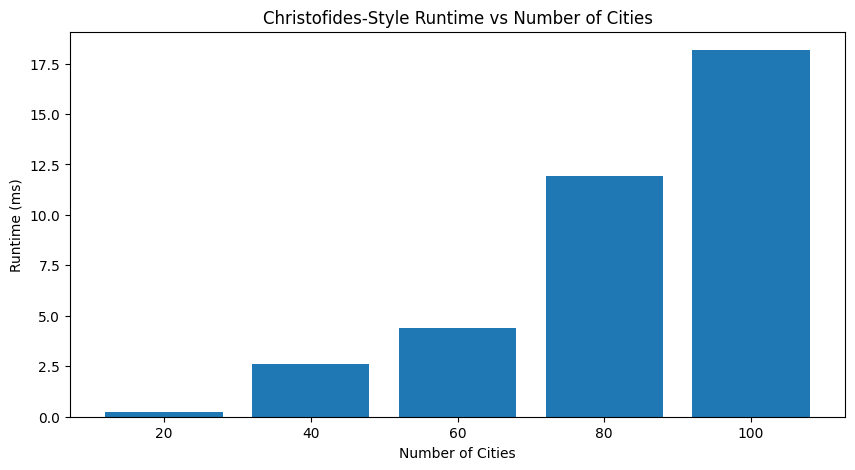

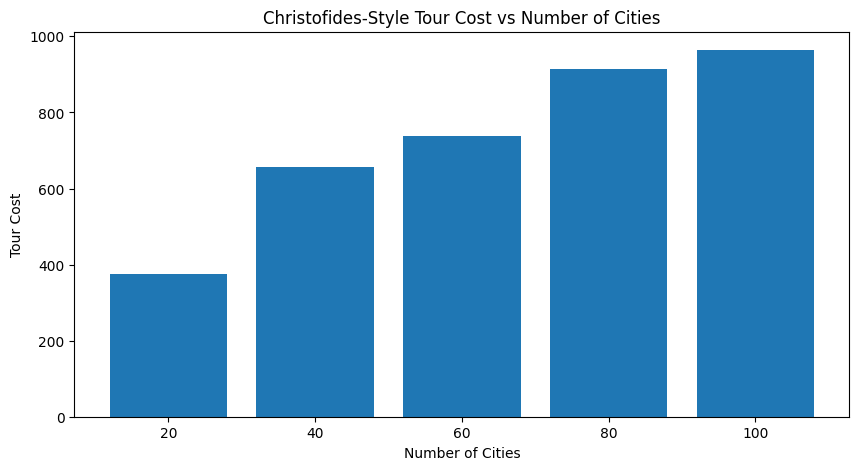

In [ ]:
import random
import time
import matplotlib.pyplot as plt

# =====================================
# Generate random cities
# =====================================
def generate_cities(num_cities, seed=42):
    random.seed(seed)
    return [{"x": random.uniform(0, 100), "y": random.uniform(0, 100)} for _ in range(num_cities)]

# =====================================
# Build distance matrix from city list
# =====================================
def build_distance_matrix(cities):
    n = len(cities)
    D = [[0.0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            dx = cities[i]["x"] - cities[j]["x"]
            dy = cities[i]["y"] - cities[j]["y"]
            D[i][j] = math.sqrt(dx * dx + dy * dy)

    return D

# =====================================
# Christofides benchmark
# =====================================
def benchmark_christofides(num_cities, seed=42):
    cities = generate_cities(num_cities, seed)
    D = build_distance_matrix(cities)

    t0 = time.time()
    result = christofides_style_tsp(D)
    elapsed = (time.time() - t0) * 1000

    return {
        "size": num_cities,
        "runtime": elapsed,
        "cost": result["cost"],
        "tour": result["tour"]
    }

# =====================================
# Run multiple experiments
# =====================================
def run_christofides_experiments(sizes):
    runtimes = []
    costs = []

    for size in sizes:
        result = benchmark_christofides(size, seed=42 + size)

        print(f"Cities: {size} | Runtime: {result['runtime']:.2f} ms | Cost: {result['cost']:.2f}")

        runtimes.append(result["runtime"])
        costs.append(result["cost"])

    return runtimes, costs

# =====================================
# Plot bar charts
# =====================================
def plot_christofides_results(sizes):
    runtimes, costs = run_christofides_experiments(sizes)

    # Runtime bar chart
    plt.figure(figsize=(10, 5))
    plt.bar([str(s) for s in sizes], runtimes)
    plt.title("Christofides-Style Runtime vs Number of Cities")
    plt.xlabel("Number of Cities")
    plt.ylabel("Runtime (ms)")
    plt.show()

    # Tour cost bar chart
    plt.figure(figsize=(10, 5))
    plt.bar([str(s) for s in sizes], costs)
    plt.title("Christofides-Style Tour Cost vs Number of Cities")
    plt.xlabel("Number of Cities")
    plt.ylabel("Tour Cost")
    plt.show()

# =====================================
# RUN THIS
# =====================================
plot_christofides_results([20, 40, 60, 80, 100])